## Targetweight = sum of all cweights - Same catergory


In [1]:
import copy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

###############
# User inputs #
###############

# Initial number of NFTs for each category
initial_nft_supply = {
    'expert': {'NFT1': 1},
    'graduate': {'NFT1': 10},
    'student': {'NFT1': 20}
}

# Initial weight of NFTs for each category
nft_score = {
    'expert': {'NFT1': 1},
    'graduate': {'NFT1': 1},
    'student': {'NFT1': 1}
}

# NFT supply to be added per iteration
supply_updates = {
    'expert': {'NFT1': 1},
    'graduate': {'NFT1': 0},
    'student': {'NFT1': 0}
}

iterations = 100
colors = {'expert': 'blue', 'graduate': 'green', 'student': 'red'}
line_styles = {'NFT1': '--', 'NFT2': ':'}

##################################
## Store the evolution of values #
##################################

# Copy of nft_supply for use in calculations
nft_supply = copy.deepcopy(initial_nft_supply)

# Initialize lists to store simulation results
target_weights = []
total_amounts = defaultdict(list)
category_weights = defaultdict(list)
multipliers = defaultdict(list)
multiplier_increases = defaultdict(list)

# Initialize nested defaultdicts for NFT tracking
nft_supplies = defaultdict(lambda: defaultdict(list))
nft_weights = defaultdict(lambda: defaultdict(list))
nft_weight_increases = defaultdict(lambda: defaultdict(list))

################
## Simulation ##
################

# Simulation over iterations
for i in range(iterations):
    # Increase the number of NFTs and store the sum
    for category in nft_supply:
        for nft_type in nft_supply[category]:
            # Test if first round, if so don't increment
            if i != 0:
              nft_supply[category][nft_type] += supply_updates[category][nft_type]
            # Store supply
            nft_supplies[category][nft_type].append(nft_supply[category][nft_type])

    # Calculate and store category weights
    category_weight = {}
    for category in nft_supply:
        total = 0
        for nft_type in nft_supply[category]:
          total += nft_supply[category][nft_type] * nft_score[category][nft_type]
        category_weight[category] = total
        # Store weight
        category_weights[category].append(total)

    # Calculate and store target weight
    target_weight = category_weight['expert'] + category_weight['graduate'] + category_weight['student']
    target_weights.append(target_weight)

    for category in nft_supply:
        # Calculate and store total amounts per category
        total = sum(nft_supply[category].values())
        total_amounts[category].append(total)

        # Calculate multipliers and new NFT weights
        if category_weight[category] != 0:
            multiplier = target_weight / category_weight[category]
        else:
            multiplier = target_weight
        multipliers[category].append(multiplier)

        if i != 0:
            mult_diff = multiplier - multipliers[category][-2]
            multiplier_increases[category].append(mult_diff)

        # Update NFT weights based on multiplier
        for nft_type in nft_score[category]:
            new_weight = nft_score[category][nft_type] * multiplier
            nft_weights[category][nft_type].append(new_weight)

            if i != 0:
              diff = new_weight - nft_weights[category][nft_type][-2]
              nft_weight_increases[category][nft_type].append(diff)


## Results Verification

In [2]:
##################
## Verification ##
##################

for i in [0, iterations // 2, iterations - 1]:
    print(f"\nIteration {i}:")
    print("Target Weight:", target_weights[i])

    print("Total Supplies:")
    for category in total_amounts:
        print(f"  {category}: {total_amounts[category][i]}")
    print("Category Weights:")
    for category in category_weights:
        print(f"  {category}: {category_weights[category][i]}")
    print("Multipliers:")
    for category in multipliers:
        print(f"  {category}: {multipliers[category][i]}")

    for category in multipliers:
        if(category_weights[category][i] * multipliers[category][i] == target_weights[i]):
            print("SUCESSS")
        else:
            print("FAILURE")

        print(f"{category_weights[category][i]} * {multipliers[category][i]} = {target_weights[i]}")



Iteration 0:
Target Weight: 31
Total Supplies:
  expert: 1
  graduate: 10
  student: 20
Category Weights:
  expert: 1
  graduate: 10
  student: 20
Multipliers:
  expert: 31.0
  graduate: 3.1
  student: 1.55
SUCESSS
1 * 31.0 = 31
SUCESSS
10 * 3.1 = 31
SUCESSS
20 * 1.55 = 31

Iteration 50:
Target Weight: 81
Total Supplies:
  expert: 51
  graduate: 10
  student: 20
Category Weights:
  expert: 51
  graduate: 10
  student: 20
Multipliers:
  expert: 1.588235294117647
  graduate: 8.1
  student: 4.05
SUCESSS
51 * 1.588235294117647 = 81
SUCESSS
10 * 8.1 = 81
SUCESSS
20 * 4.05 = 81

Iteration 99:
Target Weight: 130
Total Supplies:
  expert: 100
  graduate: 10
  student: 20
Category Weights:
  expert: 100
  graduate: 10
  student: 20
Multipliers:
  expert: 1.3
  graduate: 13.0
  student: 6.5
SUCESSS
100 * 1.3 = 130
SUCESSS
10 * 13.0 = 130
SUCESSS
20 * 6.5 = 130


## Targetweight = sum of all cweights - Across category all


In [ ]:
import copy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

###############
# User inputs #
###############

# NFT supply to be added per iteration
supply_updates_1 = {
    'expert': {'NFT1': 0},
    'graduate': {'NFT1': 1},
    'student': {'NFT1': 1}
}

##################################
## Store the evolution of values #
##################################

# Copy of nft_supply for use in calculations
nft_supply = copy.deepcopy(initial_nft_supply)

# Initialize lists to store simulation results
target_weights_1 = []
total_amounts_1 = defaultdict(list)
category_weights_1 = defaultdict(list)
multipliers_1 = defaultdict(list)
multiplier_increases_1 = defaultdict(list)

# Initialize nested defaultdicts for NFT tracking
nft_supplies_1 = defaultdict(lambda: defaultdict(list))
nft_weights_1 = defaultdict(lambda: defaultdict(list))
nft_weight_increases_1 = defaultdict(lambda: defaultdict(list))

################
## Simulation ##
################

# Simulation over iterations
for i in range(iterations):
    # Increase the number of NFTs and store the sum
    for category in nft_supply:
        for nft_type in nft_supply[category]:
            # Test if first round, if so don't increment
            if i != 0:
              nft_supply[category][nft_type] += supply_updates_1[category][nft_type]
            # Store supply
            nft_supplies_1[category][nft_type].append(nft_supply[category][nft_type])

    # Calculate and store category weights
    category_weight = {}
    for category in nft_supply:
        total = 0
        for nft_type in nft_supply[category]:
          total += nft_supply[category][nft_type] * nft_score[category][nft_type]
        category_weight[category] = total
        # Store weight
        category_weights_1[category].append(total)

    # Calculate and store target weight
    target_weight = category_weight['expert'] + category_weight['graduate'] + category_weight['student']
    target_weights_1.append(target_weight)

    # Calculate and store total amounts per category
    for category in nft_supply:
        total = sum(nft_supply[category].values())
        total_amounts_1[category].append(total)

    # Calculate multipliers_1 and new NFT weights
    for category in nft_supply:
        if category_weight[category] != 0:
            multiplier = target_weight / category_weight[category]
        else:
            multiplier = target_weight # changed float('inf') to = target_weight for clarity
        multipliers_1[category].append(multiplier)
        if i != 0:
            mult_diff = multiplier - multipliers_1[category][-2]
            multiplier_increases_1[category].append(mult_diff)

        # Update NFT weights based on multiplier
        for nft_type in nft_score[category]:
            new_weight = nft_score[category][nft_type] * multiplier
            nft_weights_1[category][nft_type].append(new_weight)

            if i != 0:
              diff = new_weight - nft_weights_1[category][nft_type][-2]
              nft_weight_increases_1[category][nft_type].append(diff)


## Results Verification

In [ ]:
##################
## Verification ##
##################

for i in [0, iterations // 2, iterations - 1]:
    print(f"\nIteration {i}:")
    print("Target Weight:", target_weights_1[i])

    print("Total Supplies:")
    for category in total_amounts_1:
        print(f"  {category}: {total_amounts_1[category][i]}")
    print("Category Weights:")
    for category in category_weights_1:
        print(f"  {category}: {category_weights_1[category][i]}")
    print("Multipliers:")
    for category in multipliers_1:
        print(f"  {category}: {multipliers_1[category][i]}")

    for category in multipliers_1:
        if(category_weights_1[category][i] * multipliers_1[category][i] == target_weights_1[i]):
            print("SUCESSS")
        else:
            print("FAILURE")

        print(f"{category_weights_1[category][i]} * {multipliers_1[category][i]} = {target_weights_1[i]}")



Iteration 0:
Target Weight: 31
Total Supplies:
  expert: 1
  graduate: 10
  student: 20
Category Weights:
  expert: 1
  graduate: 10
  student: 20
Multipliers:
  expert: 31.0
  graduate: 3.1
  student: 1.55
SUCESSS
1 * 31.0 = 31
SUCESSS
10 * 3.1 = 31
SUCESSS
20 * 1.55 = 31

Iteration 50:
Target Weight: 131
Total Supplies:
  expert: 1
  graduate: 60
  student: 70
Category Weights:
  expert: 1
  graduate: 60
  student: 70
Multipliers:
  expert: 131.0
  graduate: 2.183333333333333
  student: 1.8714285714285714
SUCESSS
1 * 131.0 = 131
SUCESSS
60 * 2.183333333333333 = 131
SUCESSS
70 * 1.8714285714285714 = 131

Iteration 99:
Target Weight: 229
Total Supplies:
  expert: 1
  graduate: 109
  student: 119
Category Weights:
  expert: 1
  graduate: 109
  student: 119
Multipliers:
  expert: 229.0
  graduate: 2.1009174311926606
  student: 1.9243697478991597
SUCESSS
1 * 229.0 = 229
SUCESSS
109 * 2.1009174311926606 = 229
SUCESSS
119 * 1.9243697478991597 = 229


## Targetweight = sum of all cweights - Across category individual


In [3]:
import copy
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

###############
# User inputs #
###############

# NFT supply to be added per iteration
supply_updates_1 = {
    'expert': {'NFT1': 0},
    'graduate': {'NFT1': 0},
    'student': {'NFT1': 1}
}
# NFT supply to be added per iteration
supply_updates_2 = {
    'expert': {'NFT1': 0},
    'graduate': {'NFT1': 1},
    'student': {'NFT1': 0}
}

##################################
## Store the evolution of values #
##################################

# Copy of nft_supply for use in calculations
nft_supply = copy.deepcopy(initial_nft_supply)

# Initialize lists to store simulation results
target_weights_1 = []
total_amounts_1 = defaultdict(list)
category_weights_1 = defaultdict(list)
multipliers_1 = defaultdict(list)
multiplier_increases_1 = defaultdict(list)

# Initialize nested defaultdicts for NFT tracking
nft_supplies_1 = defaultdict(lambda: defaultdict(list))
nft_weights_1 = defaultdict(lambda: defaultdict(list))
nft_weight_increases_1 = defaultdict(lambda: defaultdict(list))

################
## Simulation ##
################

# Simulation over iterations
for i in range(iterations):
    # Increase the number of NFTs and store the sum
    for category in nft_supply:
        for nft_type in nft_supply[category]:
            # Test if first round, if so don't increment
            if i != 0:
                if i % 2 == 0:
                    nft_supply[category][nft_type] += supply_updates_1[category][nft_type]
                else:
                    nft_supply[category][nft_type] += supply_updates_2[category][nft_type]
            # Store supply
            nft_supplies_1[category][nft_type].append(nft_supply[category][nft_type])

    # Calculate and store category weights
    category_weight = {}
    for category in nft_supply:
        total = 0
        for nft_type in nft_supply[category]:
          total += nft_supply[category][nft_type] * nft_score[category][nft_type]
        category_weight[category] = total
        # Store weight
        category_weights_1[category].append(total)

    # Calculate and store target weight
    target_weight = category_weight['expert'] + category_weight['graduate'] + category_weight['student']
    target_weights_1.append(target_weight)

    # Calculate and store total amounts per category
    for category in nft_supply:
        total = sum(nft_supply[category].values())
        total_amounts_1[category].append(total)

    # Calculate multipliers_1 and new NFT weights
    for category in nft_supply:
        if category_weight[category] != 0:
            multiplier = target_weight / category_weight[category]
        else:
            multiplier = target_weight # changed float('inf') to = target_weight for clarity
        multipliers_1[category].append(multiplier)
        if i != 0:
            mult_diff = multiplier - multipliers_1[category][-2]
            multiplier_increases_1[category].append(mult_diff)

        # Update NFT weights based on multiplier
        for nft_type in nft_score[category]:
            new_weight = nft_score[category][nft_type] * multiplier
            nft_weights_1[category][nft_type].append(new_weight)

            if i != 0:
              diff = new_weight - nft_weights_1[category][nft_type][-2]
              nft_weight_increases_1[category][nft_type].append(diff)


## Results Verification

In [4]:
##################
## Verification ##
##################

for i in [0, iterations // 2, iterations - 1]:
    print(f"\nIteration {i}:")
    print("Target Weight:", target_weights_1[i])

    print("Total Supplies:")
    for category in total_amounts_1:
        print(f"  {category}: {total_amounts_1[category][i]}")
    print("Category Weights:")
    for category in category_weights_1:
        print(f"  {category}: {category_weights_1[category][i]}")
    print("Multipliers:")
    for category in multipliers_1:
        print(f"  {category}: {multipliers_1[category][i]}")

    for category in multipliers_1:
        if(category_weights_1[category][i] * multipliers_1[category][i] == target_weights_1[i]):
            print("SUCESSS")
        else:
            print("FAILURE")

        print(f"{category_weights_1[category][i]} * {multipliers_1[category][i]} = {target_weights_1[i]}")



Iteration 0:
Target Weight: 31
Total Supplies:
  expert: 1
  graduate: 10
  student: 20
Category Weights:
  expert: 1
  graduate: 10
  student: 20
Multipliers:
  expert: 31.0
  graduate: 3.1
  student: 1.55
SUCESSS
1 * 31.0 = 31
SUCESSS
10 * 3.1 = 31
SUCESSS
20 * 1.55 = 31

Iteration 50:
Target Weight: 81
Total Supplies:
  expert: 1
  graduate: 35
  student: 45
Category Weights:
  expert: 1
  graduate: 35
  student: 45
Multipliers:
  expert: 81.0
  graduate: 2.3142857142857145
  student: 1.8
SUCESSS
1 * 81.0 = 81
FAILURE
35 * 2.3142857142857145 = 81
SUCESSS
45 * 1.8 = 81

Iteration 99:
Target Weight: 130
Total Supplies:
  expert: 1
  graduate: 60
  student: 69
Category Weights:
  expert: 1
  graduate: 60
  student: 69
Multipliers:
  expert: 130.0
  graduate: 2.1666666666666665
  student: 1.8840579710144927
SUCESSS
1 * 130.0 = 130
SUCESSS
60 * 2.1666666666666665 = 130
SUCESSS
69 * 1.8840579710144927 = 130


## Results

Weight Increases
defaultdict(<function <lambda> at 0x7d13090aa840>, {'expert': defaultdict(<class 'list'>, {'NFT1': [-15.0, -5.0, -2.5, -1.5, -1.0, -0.7142857142857144, -0.5357142857142856, -0.41666666666666696, -0.33333333333333304, -0.27272727272727293, -0.22727272727272707, -0.1923076923076925, -0.1648351648351647, -0.1428571428571428, -0.125, -0.11029411764705888, -0.0980392156862746, -0.08771929824561386, -0.07894736842105265, -0.07142857142857162, -0.06493506493506462, -0.059288537549407216, -0.05434782608695654, -0.04999999999999982, -0.046153846153846434, -0.04273504273504258, -0.03968253968253954, -0.03694581280788212, -0.0344827586206895, -0.032258064516129004, -0.030241935483870996, -0.02840909090909083, -0.02673796791443861, -0.025210084033613356, -0.023809523809523947, -0.022522522522522515, -0.021337126600284417, -0.020242914979757165, -0.019230769230769162, -0.018292682926829285, -0.017421602787456525, -0.01661129568106312, -0.01585623678646919, -0.015151515151515138, -0

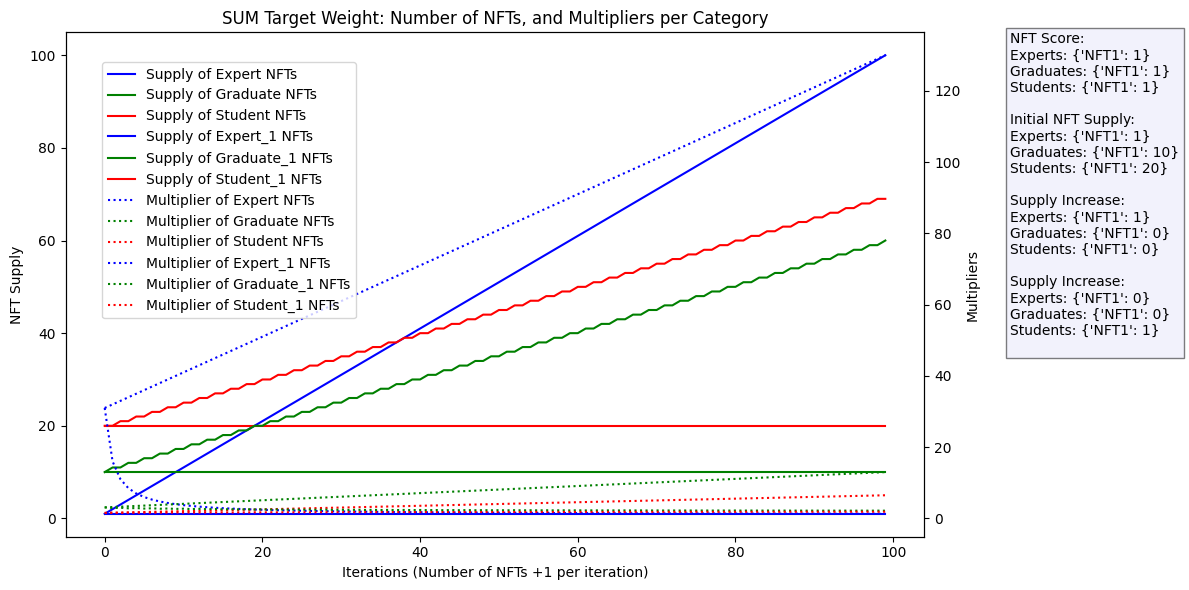

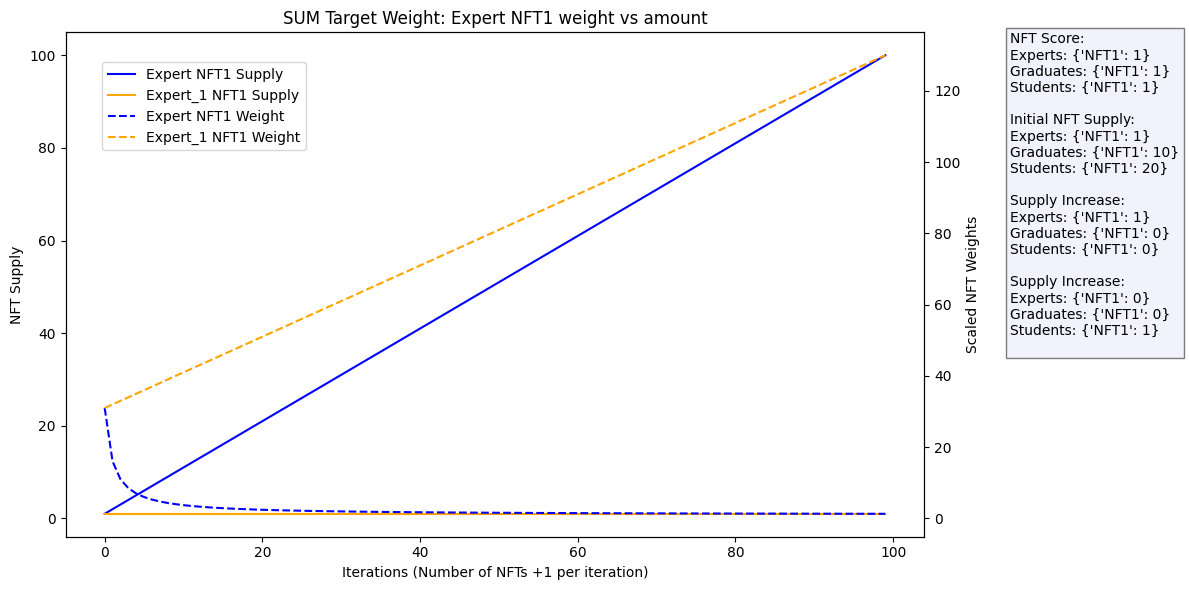

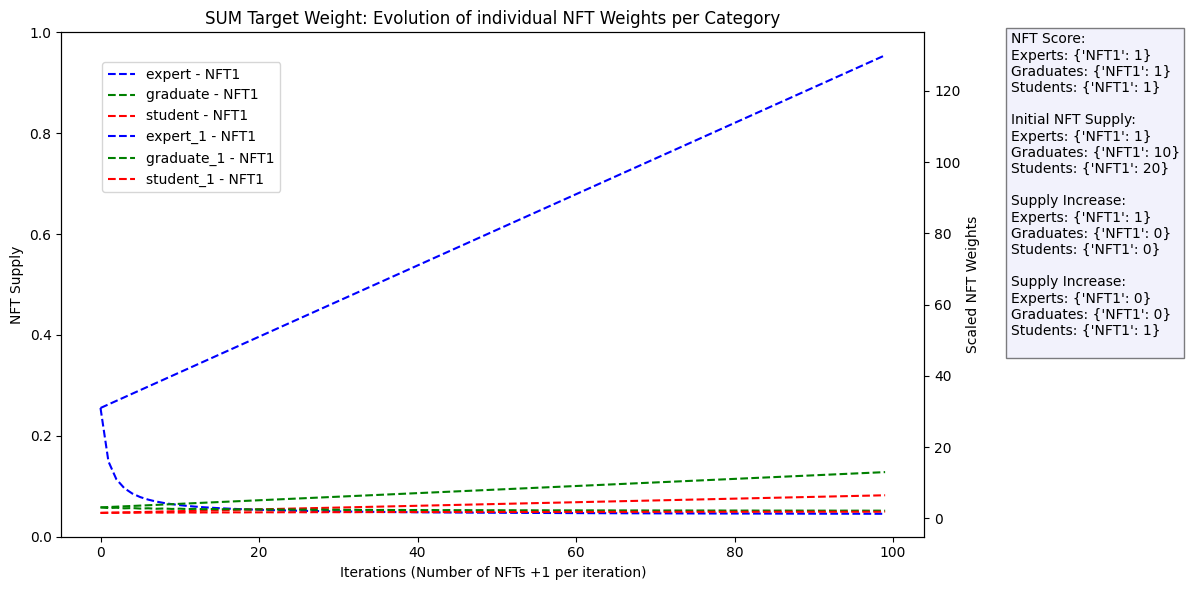

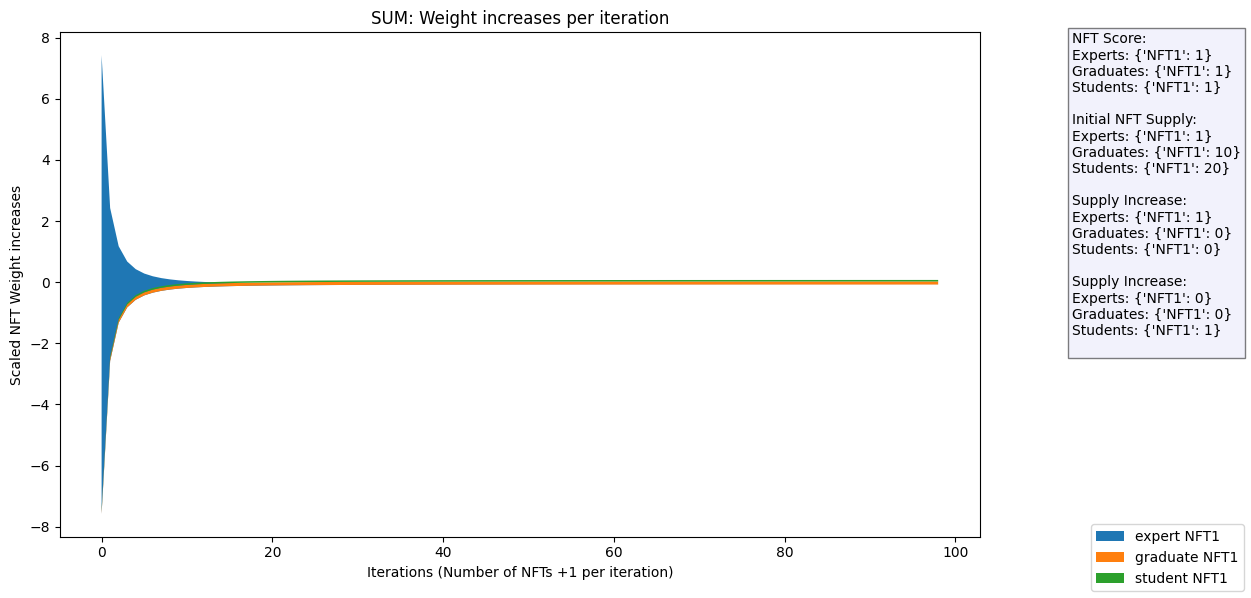

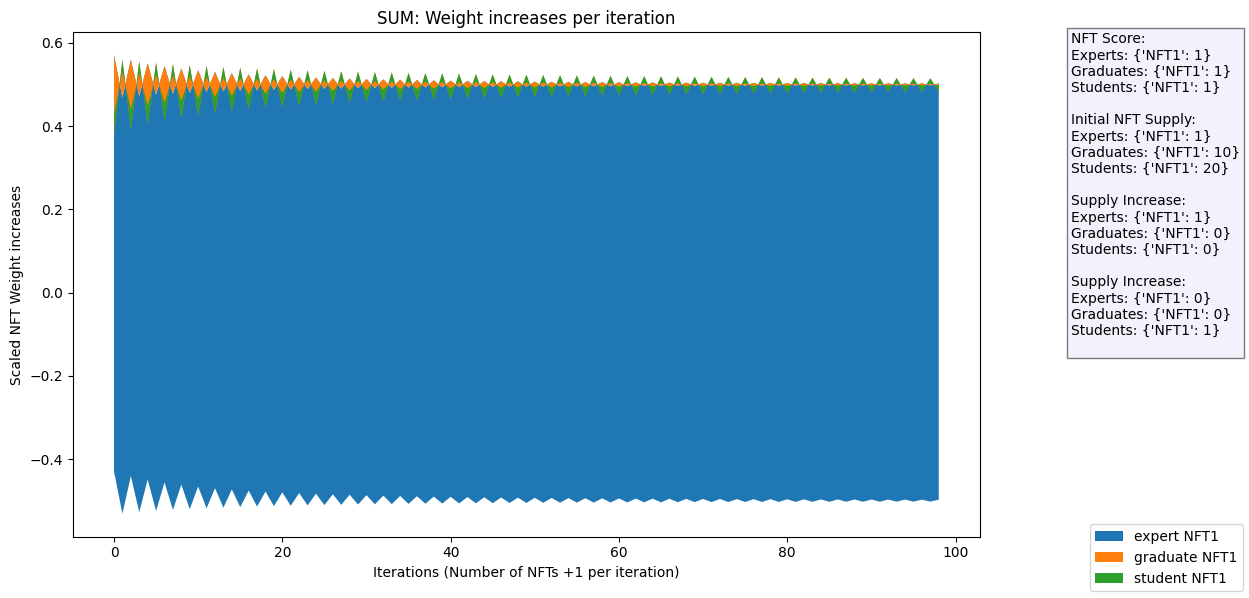

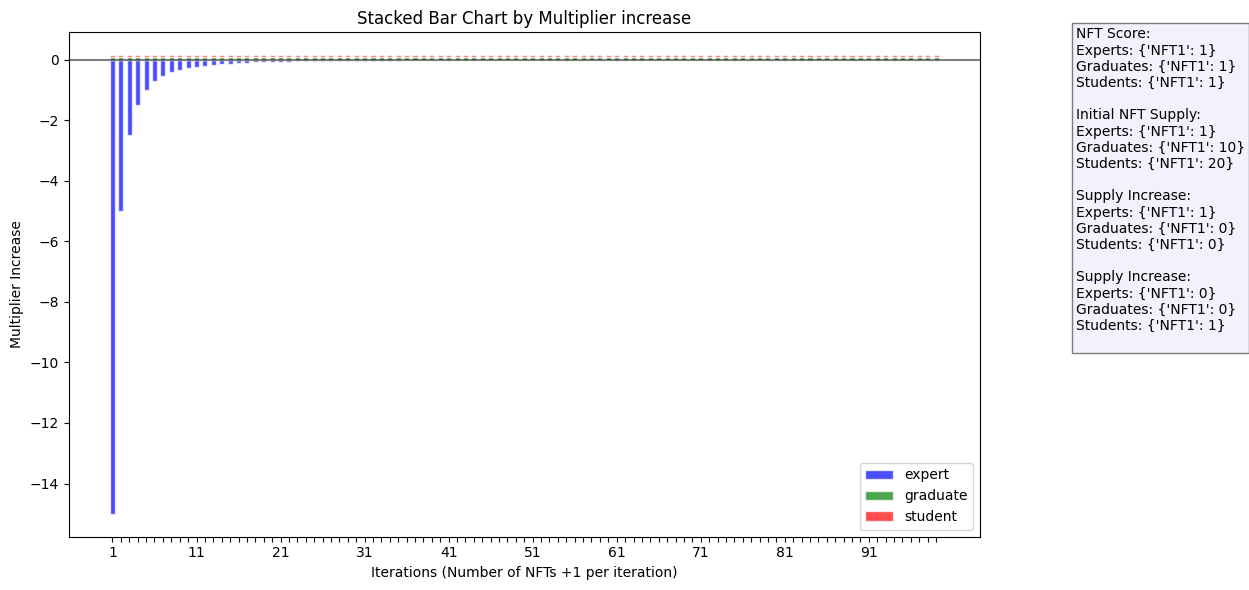

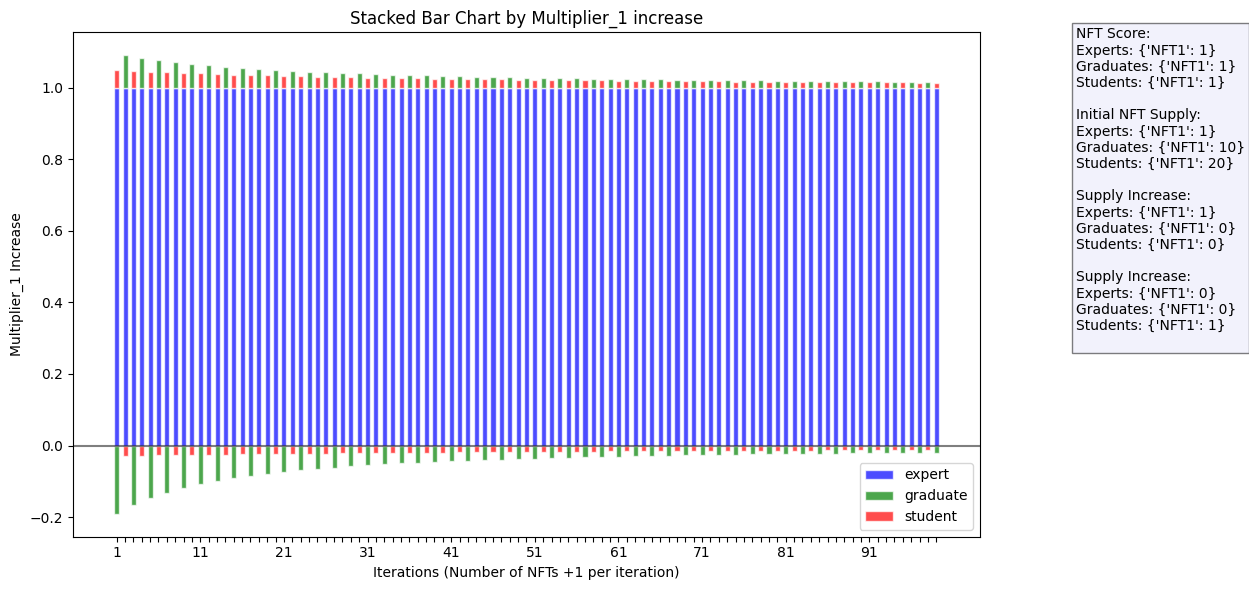

In [5]:
#############
## RESULTS ##
#############

#print("Multipliers")
#print(multipliers)
#print("Category weights")
#print(category_weights)
#print("New weights")
#print(new_nft_weights)
print("Weight Increases")
print(nft_weight_increases)


############
## GRAPHS ##
############

### Text box for graph clarity ###
textbox = '\n'.join([
    'NFT Score:',
    f"Experts: {nft_score['expert']}",
    f"Graduates: {nft_score['graduate']}",
    f"Students: {nft_score['student']}",
    '',
    'Initial NFT Supply:',
    f"Experts: {initial_nft_supply['expert']}",
    f"Graduates: {initial_nft_supply['graduate']}",
    f"Students: {initial_nft_supply['student']}",
    '',
    'Supply Increase:',
    f"Experts: {supply_updates['expert']}",
    f"Graduates: {supply_updates['graduate']}",
    f"Students: {supply_updates['student']}",
    '',
    'Supply Increase:',
    f"Experts: {supply_updates_1['expert']}",
    f"Graduates: {supply_updates_1['graduate']}",
    f"Students: {supply_updates_1['student']}",
    '',
])

### Multipliers ###
# print the multiplier graphs

# Create the total weights plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

# Plot target_weight and number of NFTs on the primary y-axis (ax1)
for category in total_amounts:
    ax1.plot(range(iterations), total_amounts[category], label=f'Supply of {category.capitalize()} NFTs', color=colors[category])
for category in total_amounts:
    ax1.plot(range(iterations), total_amounts_1[category], label=f'Supply of {category.capitalize()}_1 NFTs', color=colors[category])

# Set labels for the primary y-axis
ax1.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax1.set_ylabel('NFT Supply')
ax1.set_title('SUM Target Weight: Number of NFTs, and Multipliers per Category')

# Create the secondary y-axis (ax2) for multipliers
ax2 = ax1.twinx()

# Plot multipliers for each category on the secondary y-axis (ax2)
for category in multipliers:
    ax2.plot(range(iterations), multipliers[category], label=f'Multiplier of {category.capitalize()} NFTs', color=colors[category], linestyle=':')
for category in multipliers:
    ax2.plot(range(iterations), multipliers_1[category], label=f'Multiplier of {category.capitalize()}_1 NFTs', color=colors[category], linestyle=':')

# Set labels for the secondary y-axis
ax2.set_ylabel('Multipliers')

# Combine legends from both y-axes
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Show the plot
plt.tight_layout()
plt.show()

#### NFT1 supply vs NFT1 weight ####
# Print the weight and number of the NFT being changed

# Create the individual weights plot
fig, ax1 = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

# Plot target_weight and number of NFTs on the primary y-axis (ax1)
ax1.plot(range(iterations), nft_supplies['expert']['NFT1'], label='Expert NFT1 Supply', color=colors['expert'])
ax1.plot(range(iterations), nft_supplies_1['expert']['NFT1'], label='Expert_1 NFT1 Supply', color='orange')

# Set labels for the primary y-axis
ax1.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax1.set_ylabel('NFT Supply')
ax1.set_title('SUM Target Weight: Expert NFT1 weight vs amount')

# Create the secondary y-axis (ax2) for multipliers
ax2 = ax1.twinx()
ax2.set_ylabel('Scaled NFT Weights')

# Plot individual NFT weight
ax2.plot(range(iterations), nft_weights['expert']['NFT1'], label='Expert NFT1 Weight', color=colors['expert'], linestyle=line_styles['NFT1'])
ax2.plot(range(iterations), nft_weights_1['expert']['NFT1'], label='Expert_1 NFT1 Weight', color='orange', linestyle=line_styles['NFT1'])

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Show the plot
plt.tight_layout()
plt.show()

#### Individual NFT weights ####
# Print the weights of all NFTs over time

# Create the individual weights plot
fig, ax1 = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

# Plot target_weight and number of NFTs on the primary y-axis (ax1)
#ax1.plot(range(iterations), nft_supplies['expert']['NFT1'], label='Expert NFT1 Supply', color=colors['expert'])
#ax1.plot(range(iterations), nft_supplies['graduate']['NFT1'], label='Granduate NFT1 Supply', color=colors['graduate'])
#ax1.plot(range(iterations), nft_supplies['student']['NFT1'], label='Student NFT1 Supply', color=colors['student'])
for category in nft_weights:
    values = nft_supplies[category]['NFT1']
    ax2.plot(range(iterations), values, label=f'{category} NFT1 Supply', color=colors[category], linestyle=line_styles['NFT1'])
for category in nft_weights:
    values = nft_supplies_1[category]['NFT1']
    ax2.plot(range(iterations), values, label=f'{category} NFT1 Supply', color=colors[category], linestyle=line_styles['NFT1'])

# Set labels for the primary y-axis
ax1.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax1.set_ylabel('NFT Supply')
ax1.set_title('SUM Target Weight: Evolution of individual NFT Weights per Category')

# Create the secondary y-axis (ax2) for multipliers
ax2 = ax1.twinx()
ax2.set_ylabel('Scaled NFT Weights')

# Plot individual NFT weights
for category in nft_weights:
    values = nft_weights[category]['NFT1']
    ax2.plot(range(iterations), values, label=f'{category} - NFT1', color=colors[category], linestyle=line_styles['NFT1'])
for category in nft_weights_1:
    values = nft_weights_1[category]['NFT1']
    ax2.plot(range(iterations), values, label=f'{category}_1 - NFT1', color=colors[category], linestyle=line_styles['NFT1'])

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Show the plot
plt.tight_layout()
plt.show()

#### Weight increase vs previous ####
y = []
labels = []
fig, ax1 = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

for category in nft_weight_increases:
    for nft_type in nft_weight_increases[category]:
      y.append(nft_weight_increases[category][nft_type])
      labels.append(f"{category} {nft_type}")

ax1.stackplot(range(iterations -1), y, labels=labels, baseline='sym')

ax1.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax1.set_ylabel('Scaled NFT Weight increases')
ax1.set_title('SUM: Weight increases per iteration')

fig.legend(loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()

y = []
labels = []
fig, ax1 = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

for category in nft_weight_increases_1:
    for nft_type in nft_weight_increases_1[category]:
      y.append(nft_weight_increases_1[category][nft_type])
      labels.append(f"{category} {nft_type}")

ax1.stackplot(range(iterations -1), y, labels=labels, baseline='sym')

ax1.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax1.set_ylabel('Scaled NFT Weight increases')
ax1.set_title('SUM: Weight increases per iteration')

fig.legend(loc='lower right')

# Show the plot
plt.tight_layout()
plt.show()

#### Barchar plot multiplier increases ####
# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

x = range(iterations - 1)
width = 0.6

# For each iteration position
for i in range(iterations - 1):
    # Initialize positive and negative bottoms
    pos_bottom = 0
    neg_bottom = 0

    # Plot each category's value at this iteration
    for category in multiplier_increases:
        value = multiplier_increases[category][i]
        if value >= 0:
            ax.bar(x[i], value, width, bottom=pos_bottom,
                   color=colors[category], edgecolor='white', alpha=0.7,
                   label=category if i == 0 else "")
            pos_bottom += value
        else:
            ax.bar(x[i], value, width, bottom=neg_bottom,
                   color=colors[category], edgecolor='white', alpha=0.7,
                   label=category if i == 0 else "")
            neg_bottom += value

# Add labels and formatting
ax.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax.set_ylabel('Multiplier Increase')
ax.set_title('Stacked Bar Chart by Multiplier increase')
# Only keep labels for every 10th tick
ax.set_xticks(range(iterations - 1))
x_labels = [f'{i+1}' if i % 10 == 0 else '' for i in range(iterations - 1)]
ax.set_xticklabels(x_labels)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(10, 6))

bbox = dict(boxstyle='square', facecolor='lavender', alpha=0.5)
fig.text(1.1, 1, textbox, fontsize=10, transform=ax1.transAxes, bbox=bbox,
verticalalignment='top')

x = range(iterations - 1)
width = 0.6

# For each iteration position
for i in range(iterations - 1):
    # Initialize positive and negative bottoms
    pos_bottom = 0
    neg_bottom = 0

    # Plot each category's value at this iteration
    for category in multiplier_increases_1:
        value = multiplier_increases_1[category][i]
        if value >= 0:
            ax.bar(x[i], value, width, bottom=pos_bottom,
                   color=colors[category], edgecolor='white', alpha=0.7,
                   label=category if i == 0 else "")
            pos_bottom += value
        else:
            ax.bar(x[i], value, width, bottom=neg_bottom,
                   color=colors[category], edgecolor='white', alpha=0.7,
                   label=category if i == 0 else "")
            neg_bottom += value

# Add labels and formatting
ax.set_xlabel('Iterations (Number of NFTs +1 per iteration)')
ax.set_ylabel('Multiplier_1 Increase')
ax.set_title('Stacked Bar Chart by Multiplier_1 increase')
# Only keep labels for every 10th tick
ax.set_xticks(range(iterations - 1))
x_labels = [f'{i+1}' if i % 10 == 0 else '' for i in range(iterations - 1)]
ax.set_xticklabels(x_labels)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)

# Add legend
ax.legend()

plt.tight_layout()
plt.show()

## Rate of change tests

In [ ]:
for i in range(iterations - 1):
    print(i)
    print('Decreasse')
    print(multiplier_increases['expert'][i])
    print(multiplier_increases_1['graduate'][i] + multiplier_increases_1['student'][i])

    print('Inrease')
    print(multiplier_increases['graduate'][i] + multiplier_increases['student'][i])
    print(multiplier_increases_1['expert'][i])
    print('/n')



0
Decreasse
-15.0
-0.07857142857142874
Inrease
0.15000000000000013
2.0
/n
1
Decreasse
-5.0
-0.06385281385281405
Inrease
0.14999999999999947
2.0
/n
2
Decreasse
-2.5
-0.05272625924799801
Inrease
0.15000000000000013
2.0
/n
3
Decreasse
-1.5
-0.04413521261347375
Inrease
0.15000000000000013
2.0
/n
4
Decreasse
-1.0
-0.03738095238095229
Inrease
0.15000000000000013
2.0
/n
5
Decreasse
-0.7142857142857144
-0.03198717948717955
Inrease
0.15000000000000013
2.0
/n
6
Decreasse
-0.5357142857142856
-0.027620663650075317
Inrease
0.14999999999999947
2.0
/n
7
Decreasse
-0.41666666666666696
-0.024042950513538663
Inrease
0.15000000000000013
2.0
/n
8
Decreasse
-0.33333333333333304
-0.02107999884769396
Inrease
0.15000000000000013
2.0
/n
9
Decreasse
-0.27272727272727293
-0.018602540834846026
Inrease
0.14999999999999947
2.0
/n
10
Decreasse
-0.22727272727272707
-0.016513056835637308
Inrease
0.1500000000000008
2.0
/n
11
Decreasse
-0.1923076923076925
-0.01473694316436247
Inrease
0.14999999999999947
2.0
/n
12
Decrea

## Multiplier tests

In [ ]:
for i in range(1, 10):
  print(i)
  print(f"multipliers: {multipliers['expert'][i]}")
  print(f"multipliers: {multipliers['graduate'][i]}")
  print(f"multipliers: {multipliers['student'][i]}")
  print('/n')
  print(f"multipliers_1 {multipliers_1['expert'][i]}")
  print(f"multipliers_1 {multipliers_1['graduate'][i]}")
  print(f"multipliers_1 {multipliers_1['student'][i]}")
  print('/n')
  print(i)
  print(f"multiplier_increases {multiplier_increases['expert'][i]}")
  print(f"multiplier_increases {multiplier_increases['graduate'][i]}")
  print(f"multiplier_increases {multiplier_increases['student'][i]}")
  print('/n')
  print(f"multiplier_increases_1 {multiplier_increases_1['expert'][i]}")
  print(f"multiplier_increases_1 {multiplier_increases_1['graduate'][i]}")
  print(f"multiplier_increases_1 {multiplier_increases_1['student'][i]}")

1
multipliers: 11.5
multipliers: 23.0
multipliers: 1.15
/n
multipliers_1 24.0
multipliers_1 12.0
multipliers_1 1.1428571428571428
/n
1
multiplier_increases -3.5
multiplier_increases 1.0
multiplier_increases 0.050000000000000044
/n
multiplier_increases_1 2.0
multiplier_increases_1 -3.333333333333334
multiplier_increases_1 0.038961038961039085
2
multipliers: 8.0
multipliers: 24.0
multipliers: 1.2
/n
multipliers_1 26.0
multipliers_1 8.666666666666666
multipliers_1 1.1818181818181819
/n
2
multiplier_increases -1.75
multiplier_increases 1.0
multiplier_increases 0.050000000000000044
/n
multiplier_increases_1 2.0
multiplier_increases_1 -1.666666666666666
multiplier_increases_1 0.035573122529644285
3
multipliers: 6.25
multipliers: 25.0
multipliers: 1.25
/n
multipliers_1 28.0
multipliers_1 7.0
multipliers_1 1.2173913043478262
/n
3
multiplier_increases -1.0499999999999998
multiplier_increases 1.0
multiplier_increases 0.050000000000000044
/n
multiplier_increases_1 2.0
multiplier_increases_1 -1.0
